# Visualize raw data

In [4]:
import matplotlib.pyplot as plt
import random
import xarray as xr

In [2]:
DATA_DIR = '/media/RCPNAS/Data2/Flavia/CS-433-ML4S/dataset/'

TASK_FILES = {
    'motor': DATA_DIR + 'dataset_MOTOR_100_subjects_smoothing5mm_98thquantile_not_normalized_remove_mean_regressor_min_duration_10_rsquared.nc',
    'emotion': DATA_DIR + 'dataset_EMOTION_100_subjects_smoothing5mm_98thquantile_not_normalized_remove_mean_regressor_min_duration_10_rsquared.nc',
    'gambling': DATA_DIR + 'dataset_GAMBLING_100_subjects_smoothing5mm_98thquantile_not_normalized_remove_mean_regressor_min_duration_10_rsquared.nc',
    'wm': DATA_DIR + 'dataset_WM_30_subjects_smoothing5mm_98thquantile_not_normalized_merged_shortseq.nc',
    'language': DATA_DIR + 'dataset_LANGUAGE_100_subjects_smoothing5mm_98thquantile_not_normalized_remove_mean_regressor_min_duration_10_rsquared.nc'
}

dataset_motor = xr.open_dataset(TASK_FILES['motor'])
dataset_emotion = xr.open_dataset(TASK_FILES['emotion'])
dataset_gambling = xr.open_dataset(TASK_FILES['gambling'])
dataset_wm = xr.open_dataset(TASK_FILES['wm'])
dataset_language = xr.open_dataset(TASK_FILES['language'])

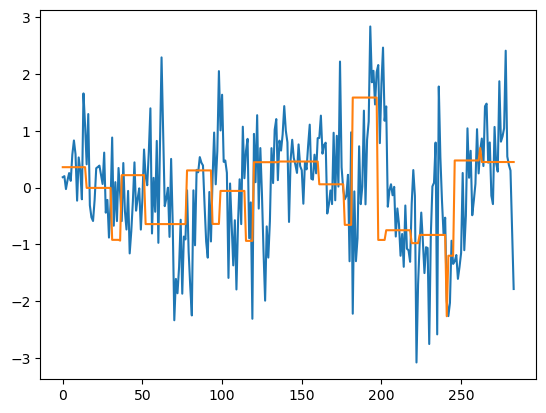

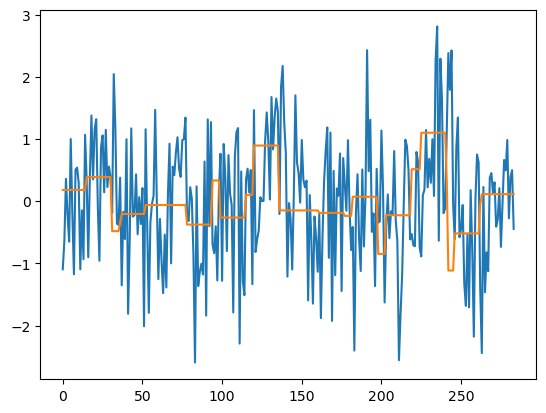

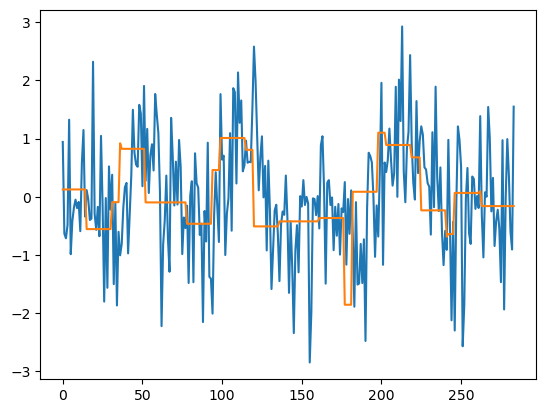

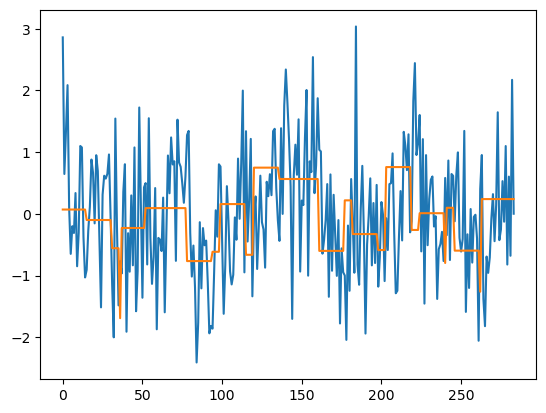

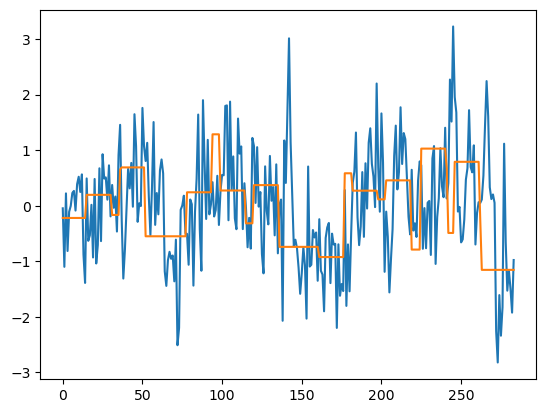

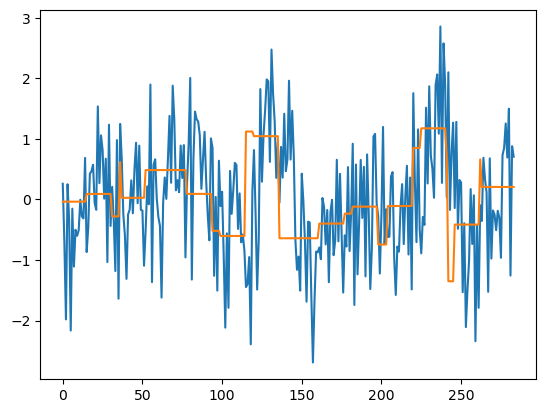

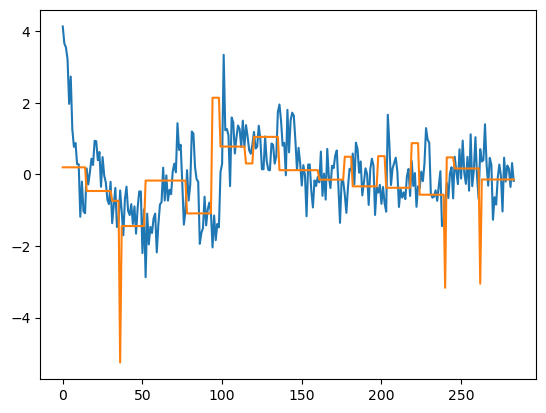

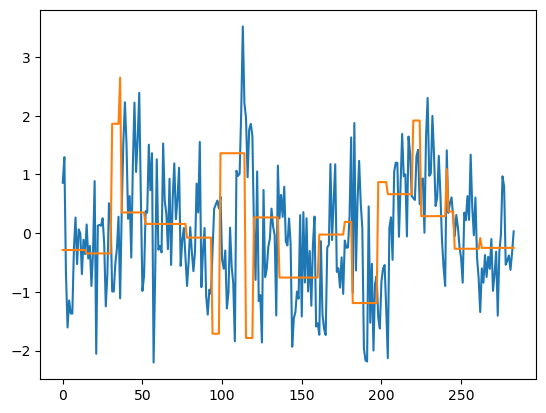

In [26]:
# Visualise motor task
for _ in range(8):
    plt.figure()
    
    random_voxel = random.randint(0, 1800)
    random_subject = random.randint(0, 100)

    plt.plot(dataset_motor.isel(voxel=random_voxel, subject=random_subject)['X'].values)
    plt.plot(dataset_motor.isel(voxel=random_voxel, subject=random_subject)['Y'].values)

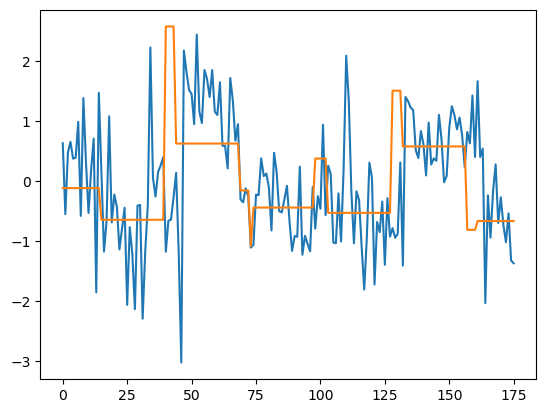

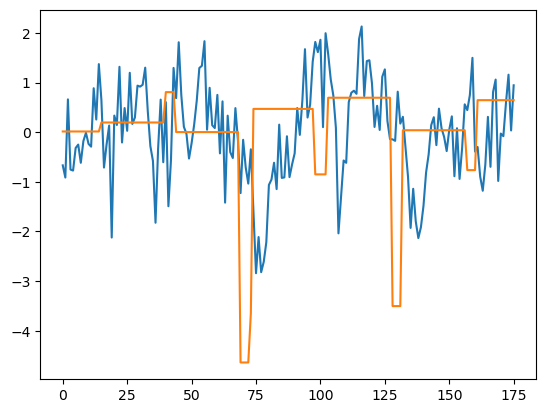

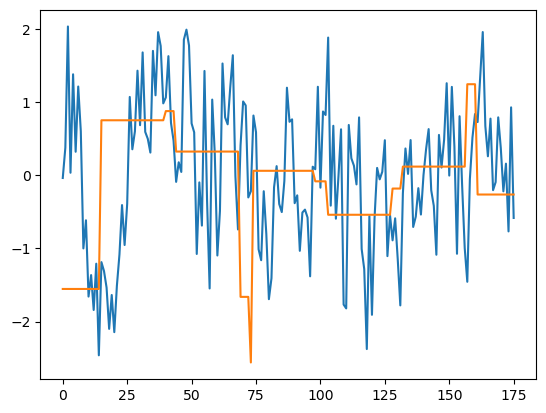

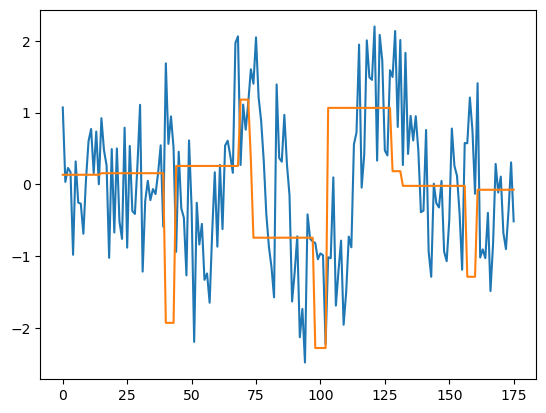

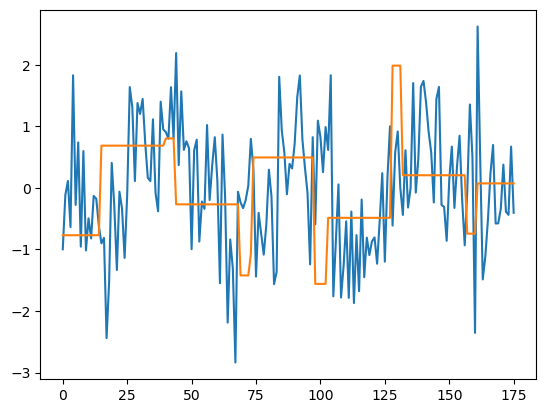

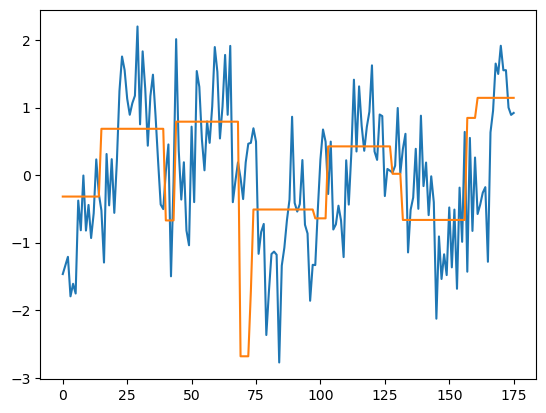

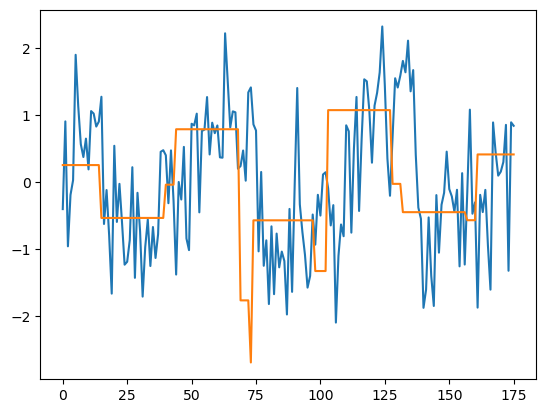

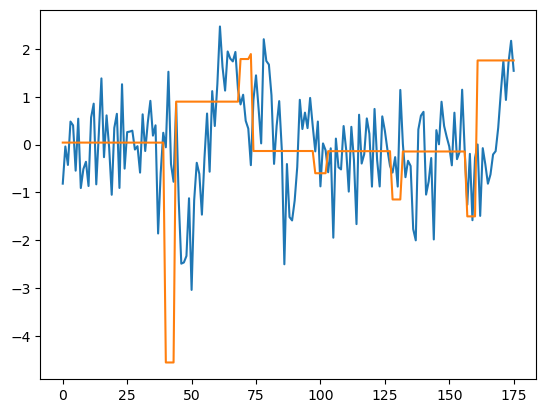

In [27]:
# Visualise emotion task
for _ in range(8):
    plt.figure()
    
    random_voxel = random.randint(0, 1800)
    random_subject = random.randint(0, 29)

    plt.plot(dataset_emotion.isel(voxel=random_voxel, subject=random_subject)['X'].values)
    plt.plot(dataset_emotion.isel(voxel=random_voxel, subject=random_subject)['Y'].values)

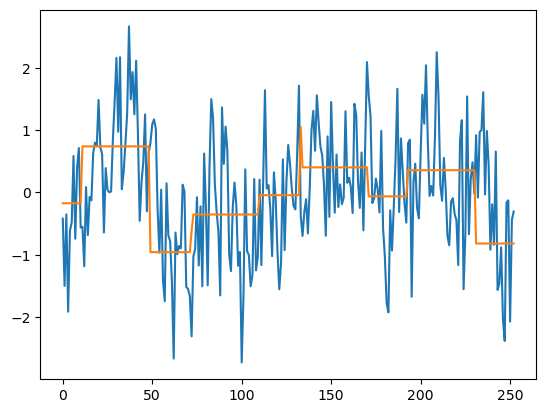

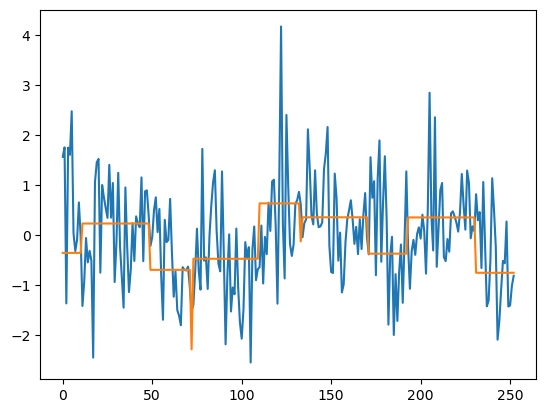

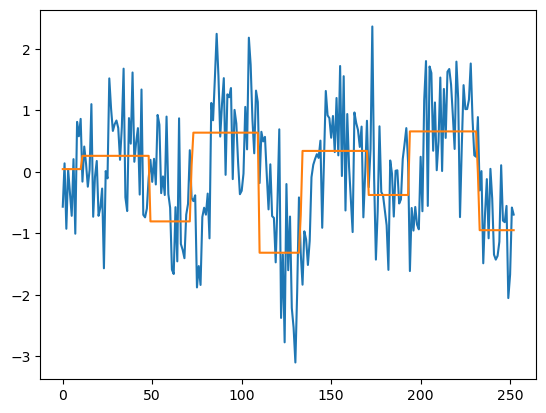

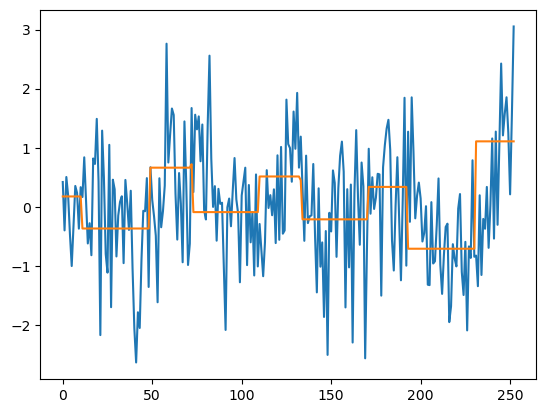

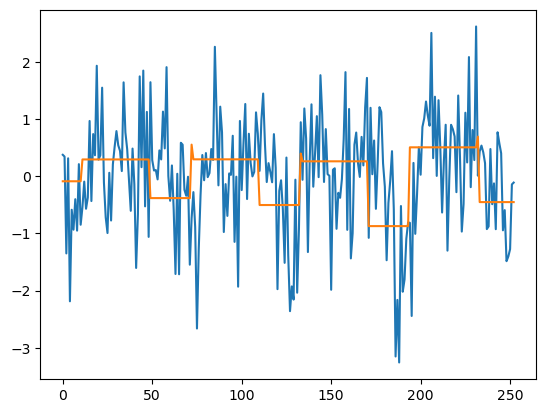

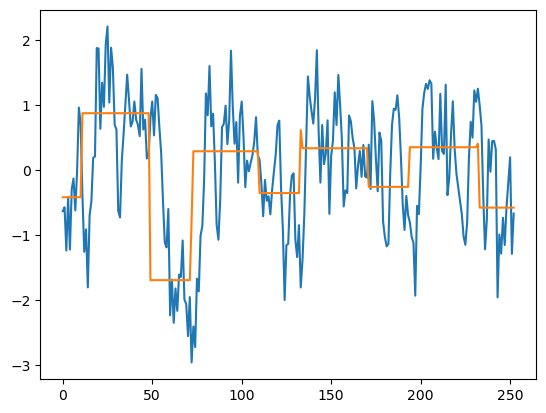

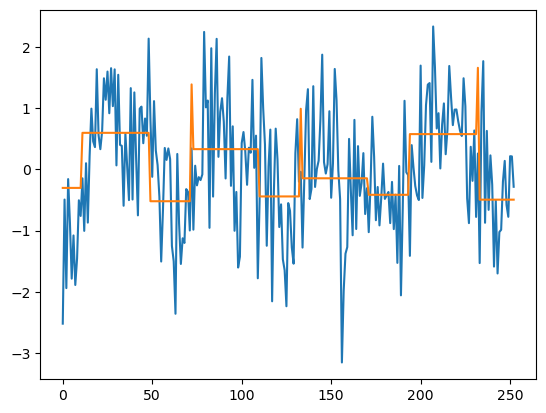

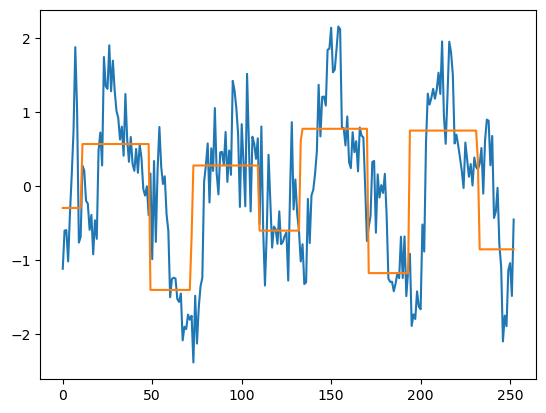

In [28]:
# Visualise gambling task
for _ in range(8):
    plt.figure()
    
    random_voxel = random.randint(0, 1800)
    random_subject = random.randint(0, 29)

    plt.plot(dataset_gambling.isel(voxel=random_voxel, subject=random_subject)['X'].values)
    plt.plot(dataset_gambling.isel(voxel=random_voxel, subject=random_subject)['Y'].values)

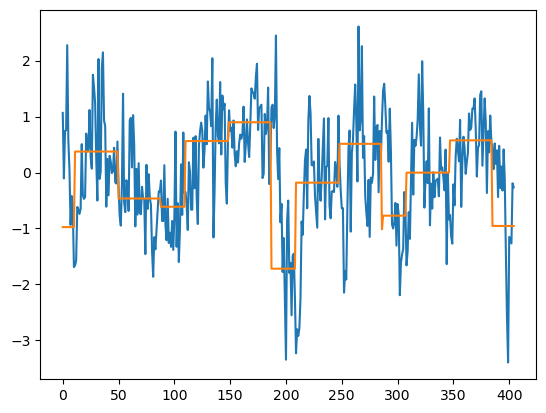

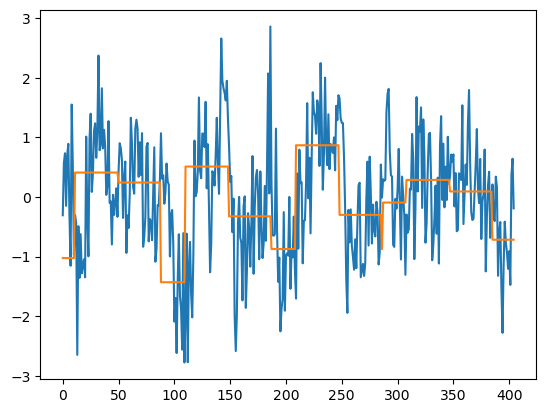

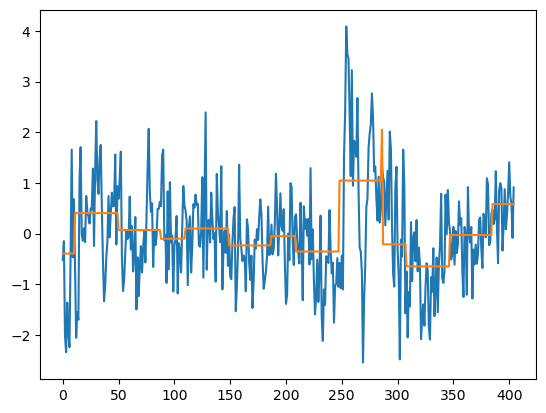

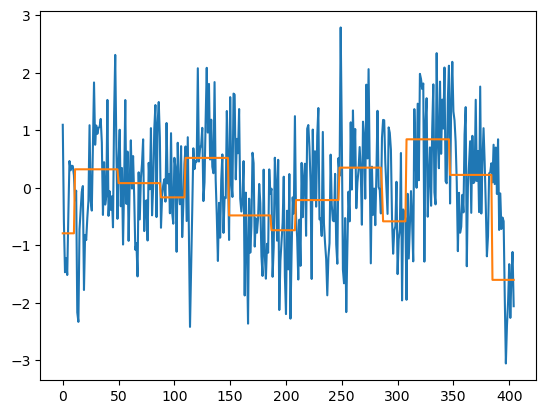

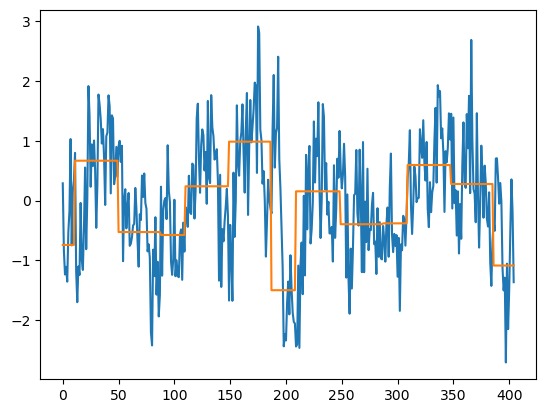

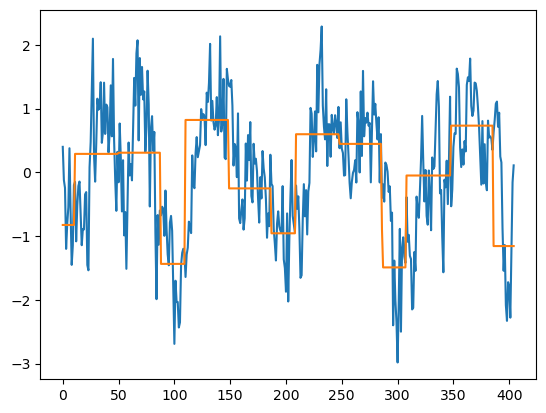

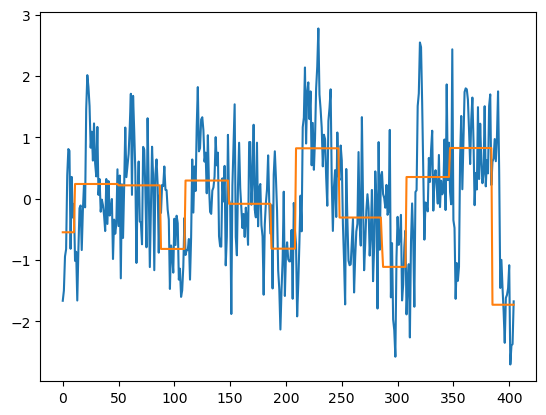

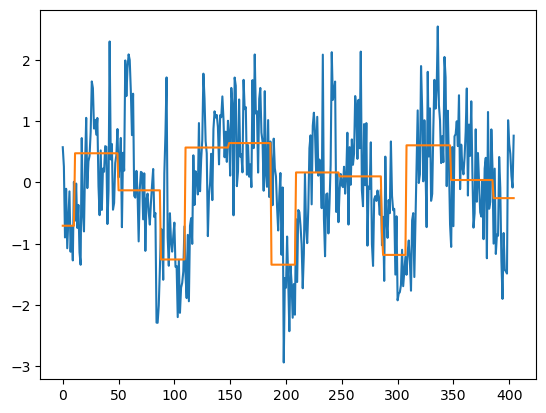

In [ ]:
# Visualise working memory task
for _ in range(8):
    plt.figure()
    
    random_voxel = random.randint(0, 1800)
    random_subject = random.randint(0, 29)

    plt.plot(dataset_wm.isel(voxel=random_voxel, subject=random_subject)['X'].values)
    plt.plot(dataset_wm.isel(voxel=random_voxel, subject=random_subject)['Y'].values)

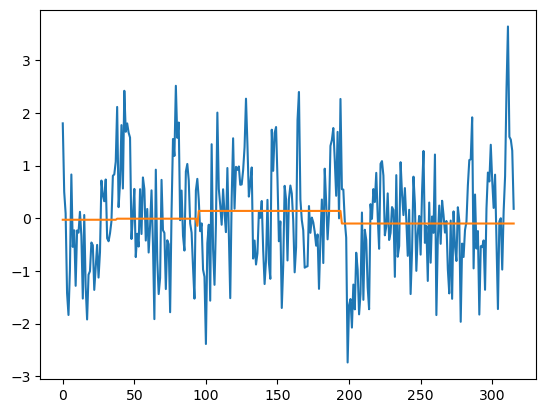

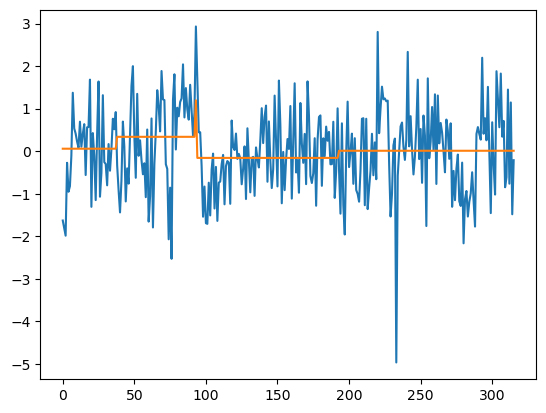

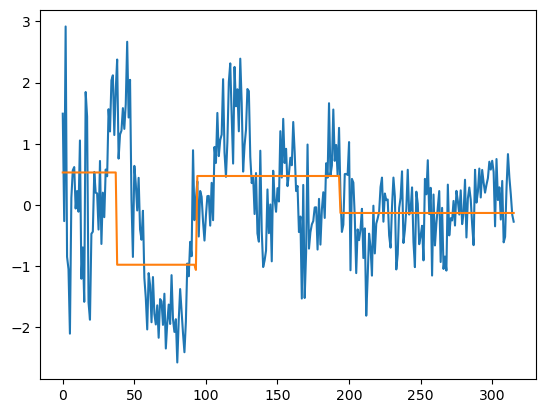

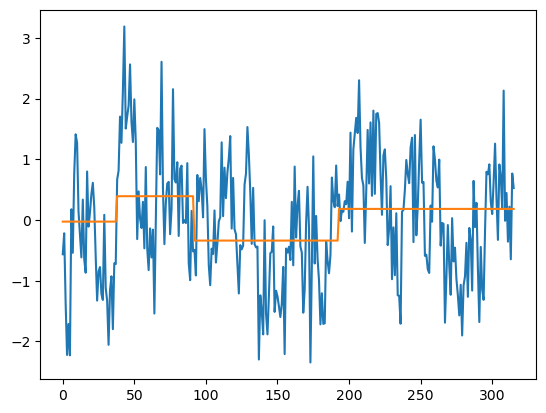

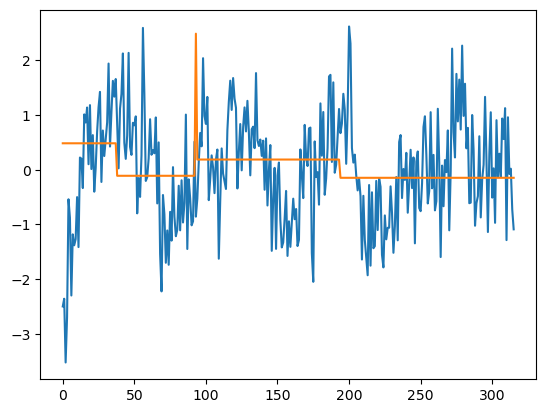

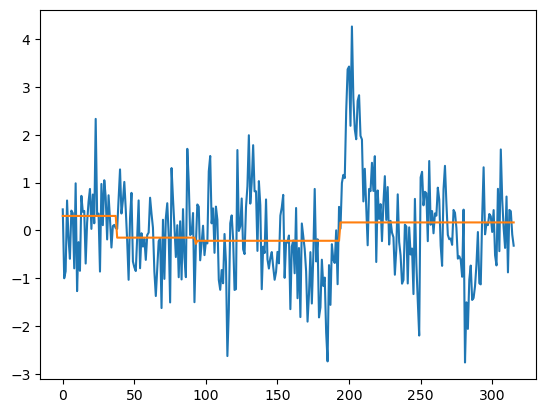

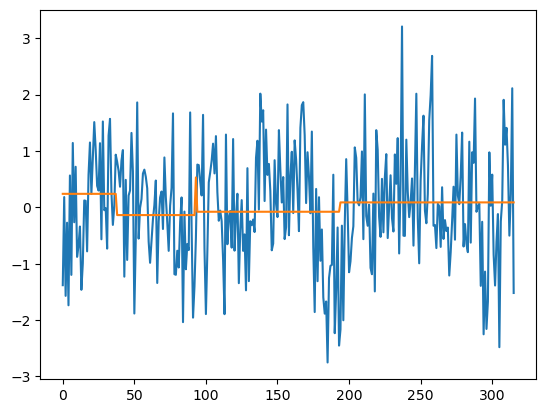

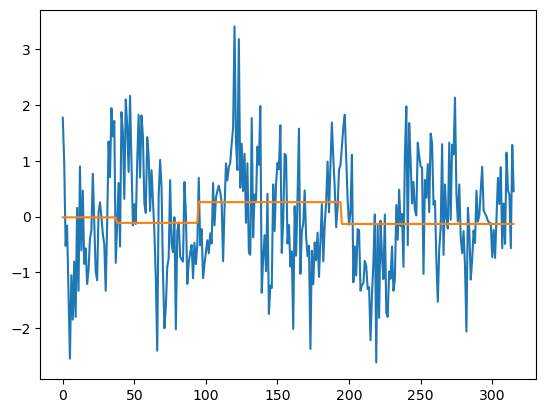

In [30]:
# Visualise language task
for _ in range(8):
    plt.figure()
    
    random_voxel = random.randint(0, 1800)
    random_subject = random.randint(0, 29)

    plt.plot(dataset_language.isel(voxel=random_voxel, subject=random_subject)['X'].values)
    plt.plot(dataset_language.isel(voxel=random_voxel, subject=random_subject)['Y'].values)

# Visualize data augmentation

In [ ]:
import numpy as np
import xarray as xr

from tools.preprocessing_functions import get_data_tensors, shift, scale_amplitude, add_gaussian_noise

/home/assaraf/.conda/envs/mip_proj/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
motor_path = '/media/RCPNAS/Data2/Flavia/CS-433-ML4S/dataset/dataset_MOTOR_100_subjects_smoothing5mm_98thquantile_not_normalized_remove_mean_regressor_min_duration_10_rsquared.nc'
dataset_motor = xr.open_dataset(motor_path)
X, y = get_data_tensors(dataset_motor, normalize=True, augmentation=False, for_test=True)

Preprocessing data as test set:


100%|███████████████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  6.75it/s]


In [22]:
X_shift, y_shift, shift_idx = shift(X, y, (20, 20))
X_scaled, y_scaled, scaled_idx = scale_amplitude(X, y, (0.75, 0.75))
X_noisy, y_noisy, noisy_idx = add_gaussian_noise(X, y, (5, 5))

augm_dict = {
    'shift': [X_shift, y_shift, shift_idx],
    'amplitude scaling': [X_scaled, y_scaled, scaled_idx],
    'gaussian noise': [X_noisy, y_noisy, noisy_idx]
}

/tmp/ipykernel_438333/364906055.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  f.tight_layout()


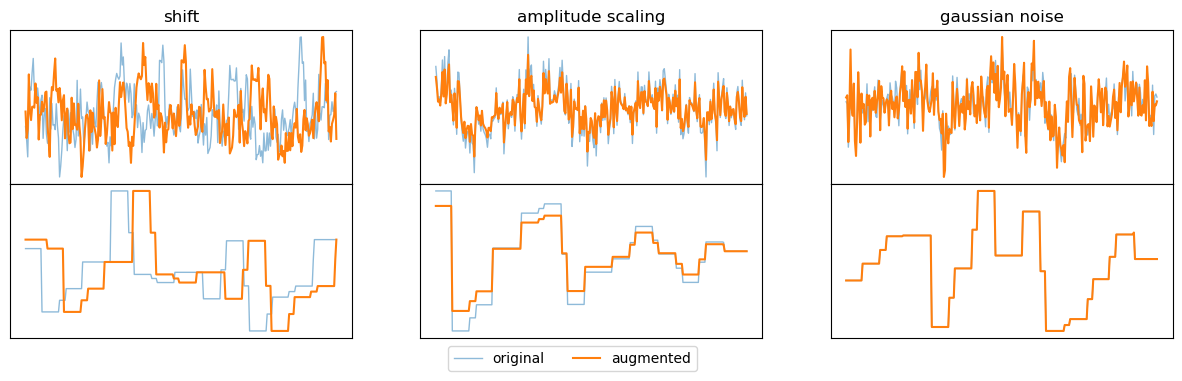

In [39]:
f, ax = plt.subplots(1, 3, figsize=(15, 4))

for a, (key, val) in zip(ax, augm_dict.items()):
    v = np.random.randint(0, 10000)
    X_augm, y_augm, idx_augm = val

    pos = a.get_position()
    height = pos.height / 2
    ax_top = f.add_axes([pos.x0, pos.y0 + height, pos.width, height])
    ax_bottom = f.add_axes([pos.x0, pos.y0, pos.width, height])
    f.delaxes(a)

    ax_top.plot(X[idx_augm[v]], alpha=0.5, linewidth=1)
    ax_top.plot(X_augm[idx_augm[v]])
    ax_top.set_title(key)
    ax_bottom.plot(y[idx_augm[v]], alpha=0.5, linewidth=1)
    ax_bottom.plot(y_augm[idx_augm[v]])

    ax_top.set_yticks([])
    ax_bottom.set_yticks([])
    ax_top.set_xticks([])
    ax_bottom.set_xticks([])

f.legend(['original', 'augmented'], loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=2)
f.tight_layout()
